In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('titanic.csv')

In [3]:
df.sample(10)

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
703,703,0,3,male,25.0,0,0,7.7417,Q,Third,man,True,NaN,Queenstown,no,True
41,41,0,2,female,27.0,1,0,21.0000,S,Second,woman,False,NaN,Southampton,no,False
720,720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
672,672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
243,243,0,3,male,22.0,0,0,7.1250,S,Third,man,True,NaN,Southampton,no,True
99,99,0,2,male,34.0,1,0,26.0000,S,Second,man,True,NaN,Southampton,no,False
820,820,1,1,female,52.0,1,1,93.5000,S,First,woman,False,B,Southampton,yes,False
431,431,1,3,female,NaN,1,0,16.1000,S,Third,woman,False,NaN,Southampton,yes,False
32,32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
130,130,0,3,male,33.0,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True


In [4]:
df=df.drop(columns=['Unnamed: 0','sex','embarked','class','who','adult_male','deck','embark_town','alive','alone'])

In [5]:
df.sample(10)

,survived,pclass,age,sibsp,parch,fare
156,1,3,16.0,0,0,7.7333
577,1,1,39.0,1,0,55.9000
355,0,3,28.0,0,0,9.5000
117,0,2,29.0,1,0,21.0000
140,0,3,NaN,0,2,15.2458
664,1,3,20.0,1,0,7.9250
143,0,3,19.0,0,0,6.7500
57,0,3,28.5,0,0,7.2292
684,0,2,60.0,1,1,39.0000
614,0,3,35.0,0,0,8.0500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   age       714 non-null    float64
 3   sibsp     891 non-null    int64  
 4   parch     891 non-null    int64  
 5   fare      891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB


In [7]:
# df['age']=df['age'].fillna(df['age'].mean())
df=df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   age       714 non-null    float64
 3   sibsp     714 non-null    int64  
 4   parch     714 non-null    int64  
 5   fare      714 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 39.0 KB


In [9]:
df.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [10]:
x=df.drop(columns=['survived'])
y=df['survived']

In [11]:
def show():
    fig , ax = plt.subplots(1,2,figsize=(12,4))
    df[df['survived']==0]['age'].plot(kind='kde',ax=ax[0],label='not survived')
    df[df['survived']==1]['age'].plot(kind='kde',ax=ax[0],label='survived')
    ax[0].set_title('Distribution of Age')
    ax[0].set_xlabel('Age')
    ax[0].legend()
    df[df['survived']==0]['fare'].plot(kind='kde',ax=ax[1],label='not survived')
    df[df['survived']==1]['fare'].plot(kind='kde',ax=ax[1],label='survived')
    ax[1].set_title('Distribution of Fare')
    ax[1].set_xlabel('Fare')
    ax[1].legend()


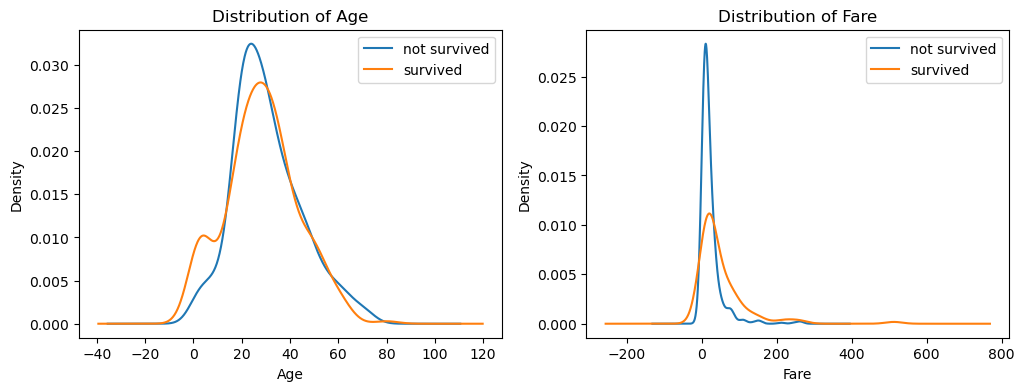

In [12]:
show()

<Axes: xlabel='age', ylabel='fare'>

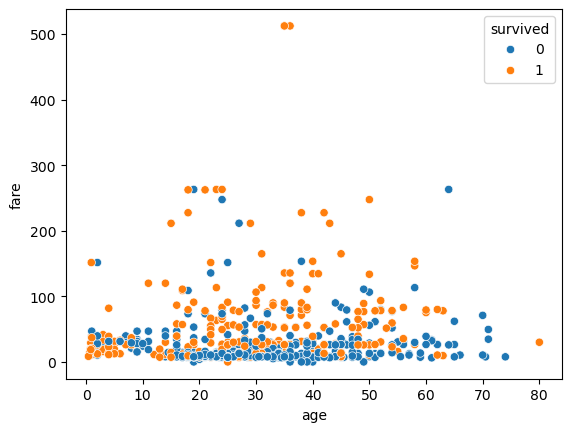

In [13]:
sns.scatterplot(x='age',y='fare',hue='survived',data=df)


In [14]:
print(df['age'].mean())
print(df['age'].std())
print(df['fare'].mean())
print(df['fare'].std())


29.69911764705882
14.526497332334044
34.694514005602244
52.9189295025436


In [15]:
from sklearn.model_selection import train_test_split;


In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model=LogisticRegression()

In [19]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred=model.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
acc=accuracy_score(y_test,y_pred)

In [23]:
acc

0.7069767441860465

### ab ham karenge standardization

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scalar=StandardScaler()

In [26]:
x_train_df=pd.DataFrame(scalar.fit_transform(x_train),columns=x_train.columns)
x_test_df=pd.DataFrame(scalar.transform(x_test),columns=x_test.columns)
x_train_df['age'].max()

3.3418468835739983

Text(0.5, 1.0, 'After Standardization')

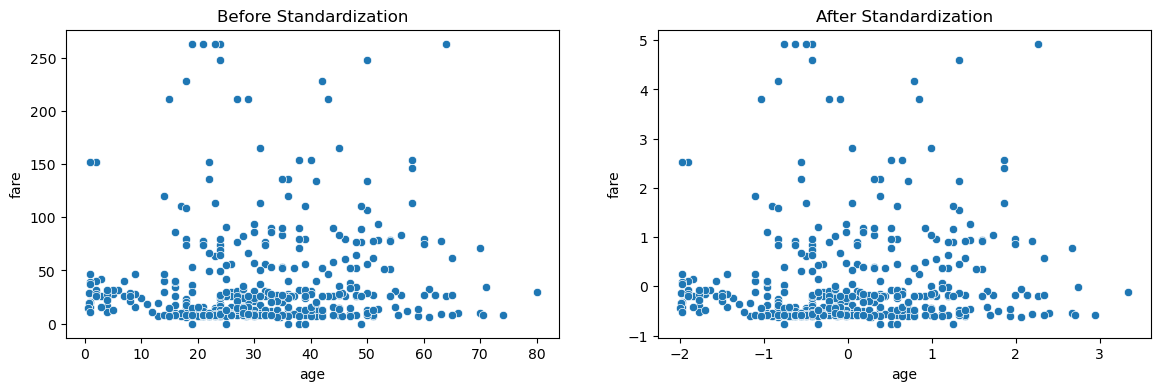

In [27]:
fig , ax = plt.subplots(1,2,figsize=(14,4))
sns.scatterplot(x='age',y='fare',data=x_train,ax=ax[0])
ax[0].set_title('Before Standardization')
sns.scatterplot(x='age',y='fare',data=x_train_df,ax=ax[1])
ax[1].set_title('After Standardization')

In [28]:
print(x_train_df['age'].mean())
print(x_train_df['age'].std())
print(x_train_df['fare'].mean())
print(x_train_df['fare'].std())

2.847866676393187e-17
1.0010035125455423
1.2637408376494768e-16
1.001003512545543


In [29]:
model2=LogisticRegression()

In [30]:
model2.fit(x_train_df,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
y_pred2=model2.predict(x_test_df)

In [32]:
acc=accuracy_score(y_test,y_pred2)

In [33]:
acc

0.7069767441860465

In [34]:
# coefficients compare karo
print(model.coef_)
print(model2.coef_)

[[-1.18115488 -0.04862058 -0.26368199  0.1473428   0.00239168]]
[[-0.99904596 -0.71458483 -0.23305208  0.13293973  0.10304141]]


### Aab karenge bawal kaam

In [35]:
x_train['fare']=x_train['fare']*10000
x_test['fare']=x_test['fare']*10000

In [36]:
x_train.sample(10)

,pclass,age,sibsp,parch,fare
543,2,32.0,1,0,260000.0
393,1,23.0,1,0,1132750.0
807,3,18.0,0,0,77750.0
218,1,32.0,0,0,762917.0
269,1,35.0,0,0,1356333.0
437,2,24.0,2,3,187500.0
592,3,47.0,0,0,72500.0
110,1,47.0,0,0,520000.0
370,1,25.0,1,0,554417.0
483,3,63.0,0,0,95875.0


In [37]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
y_pred=model.predict(x_test)

In [39]:
acc=accuracy_score(y_test,y_pred)
acc
print(model.coef_)

[[-3.67002388e-01 -2.01056711e-02 -3.29612061e-01  2.73822686e-01
   1.25034286e-06]]


In [40]:
x_train_df=pd.DataFrame(scalar.fit_transform(x_train),columns=x_train.columns)
x_test_df=pd.DataFrame(scalar.transform(x_test),columns=x_test.columns)

In [41]:
model.fit(x_train_df,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred=model.predict(x_test_df)

In [43]:
acc=accuracy_score(y_test,y_pred)
acc
print(model.coef_)

[[-0.99904596 -0.71458483 -0.23305208  0.13293973  0.10304141]]


In [44]:
print(x_train_df.corr())

          pclass       age     sibsp     parch      fare
pclass  1.000000 -0.355663  0.019711  0.034236 -0.632814
age    -0.355663  1.000000 -0.295711 -0.163877  0.109404
sibsp   0.019711 -0.295711  1.000000  0.363743  0.216900
parch   0.034236 -0.163877  0.363743  1.000000  0.257545
fare   -0.632814  0.109404  0.216900  0.257545  1.000000
